<div style="font-size: 22px;color:#000000;">
🌕 ** Install & import essentials.**  
</div>

In [54]:
!pip install -q roboflow

import os
import shutil
import cv2
import numpy as np
import matplotlib.pyplot as plt
from roboflow import Roboflow
import glob
from sklearn.metrics import classification_report
from torchvision.models import DenseNet121_Weights
from torchvision import datasets


<div style="font-size: 22px; color: teal;">
🌕 ** if we want delete old folder.**  
🌕 ** Load from Roboflow.**  
</div>

In [55]:
# Optional: Delete old folder if needed
shutil.rmtree("Phase-Your-Moon-1", ignore_errors=True)

# Load from Roboflow
rf = Roboflow(api_key="p6NVqKsj2Wr2AxGzwfhB", model_format="yolov5")
dataset = rf.workspace().project("phase-your-moon-zwpzv").version(1).download()
print("✅ Dataset downloaded to:", dataset.location)


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Phase-Your-Moon-1 in yolov5pytorch:: 100%|██████████| 1212/1212 [00:00<00:00, 2352.34it/s]

✅ Dataset downloaded to: C:\Users\WinDows\Phase-Your-Moon-1


<div style="font-size: 22px; color: teal;">
🌕 ** read images and labels.**  
</div>



In [56]:
import glob
import os

def load_data(image_dir, label_dir):
    """
    Reads YOLO-format images and labels.
    Returns a list of (image_path, class_id)
    """
    image_paths = sorted(glob.glob(os.path.join(image_dir, "*.jpg")))
    data = []

    for img_path in image_paths:
        base_name = os.path.basename(img_path).replace(".jpg", ".txt")
        label_path = os.path.join(label_dir, base_name)

        if not os.path.exists(label_path):
            continue

        with open(label_path, 'r') as f:
            first_line = f.readline().strip()
            if first_line:
                class_id = int(first_line.split()[0])  # get only the class
                data.append((img_path, class_id))

    return data

# Load all splits
base_path = r"C:Phase-Your-Moon-1"
train_data = load_data(f"{base_path}/train/images", f"{base_path}/train/labels")
valid_data = load_data(f"{base_path}/valid/images", f"{base_path}/valid/labels")
test_data  = load_data(f"{base_path}/test/images",  f"{base_path}/test/labels")

print(f"✅ Loaded: {len(train_data)} train | {len(valid_data)} valid | {len(test_data)} test")


✅ Loaded: 415 train | 119 valid | 66 test


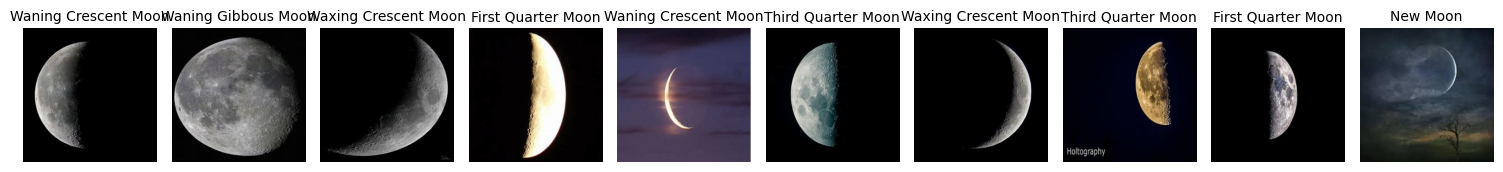

In [57]:
import cv2
import matplotlib.pyplot as plt

label_names = {
    0: "First Quarter Moon",
    1: "Full Moon",
    2: "New Moon",
    3: "Third Quarter Moon",
    4: "Waning Gibbous Moon",
    5: "Waning Crescent Moon",
    6: "Waxing Crescent Moon",
    7: "Waxing Gibbous Moon"
}


def show_sample_images(data, num=5):
    plt.figure(figsize=(15, 5))
    for i in range(num):
        img_path, label = data[i]
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

       
        label_name = label_names.get(label, f"Unknown ({label})")

        plt.subplot(1, num, i+1)
        plt.imshow(image)
        plt.title(label_name, fontsize=10)
        plt.axis('off')

    plt.tight_layout()
    plt.show()


show_sample_images(train_data, num=10)


<div style="font-size: 22px; color:#800080;">
🌕 ** Preprcessing part.**  
</div>


In [58]:
import cv2
import numpy as np
import os

def preprocess_image_and_save(input_path, output_path):
    # Step 1: Load image in grayscale
    gray = cv2.imread(input_path, cv2.IMREAD_GRAYSCALE)
    if gray is None:
        raise ValueError(f"❌ Image not found: {input_path}")

    # Step 2: Apply Gaussian Blur
    blurred = cv2.GaussianBlur(gray, (3, 3), 0)

    # Step 3: Apply Sobel operator (X and Y)
    sobel_x = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)

    # Step 4: Combine gradients to compute magnitude
    gradient_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)

    # Step 5: Normalize to [0, 1]
    gradient_magnitude /= gradient_magnitude.max() + 1e-8  # avoid division by zero

    # Step 6: Apply optional filter (currently passthrough)
   # filtered = gradient_magnitude  # you can apply custom filter here
    # Sharpening kernel
    kernel_sharpen = np.array([[0.25, 0.5, 0.25],
                           [0.5, 0.25, 0.5],
                           [0.25, 0.5, 0.25]])

    # Apply the sharpening filter to gradient magnitude
    filtered = cv2.filter2D(gradient_magnitude, -1, kernel_sharpen)

    # Step 7: Clip to [0, 1]
    clipped = np.clip(filtered, 0, 1)

    # Step 8: Convert to 8-bit (0–255) for saving
    output_img = (clipped * 255).astype(np.uint8)

    # Step 9: Save the processed image
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    cv2.imwrite(output_path, output_img)


<div style="font-size: 22px; color:#800080;">
🌕 ** code for apply all preprocess function on all data.**  
</div>


In [59]:
def preprocess_dataset(data, split_name):
    """
    data: list of (image_path, class_id)
    split_name: 'train' or 'valid' or 'test'
    """
    for i, (img_path, label) in enumerate(data):
        filename = f"image_{i}.jpg"
        output_dir = f"/content/processed/{split_name}"
        output_path = os.path.join(output_dir, filename)

        preprocess_image_and_save(img_path, output_path)



preprocess_dataset(train_data, "train")
preprocess_dataset(valid_data, "valid")
preprocess_dataset(test_data, "test")

print(" All images processed and saved!")


 All images processed and saved!


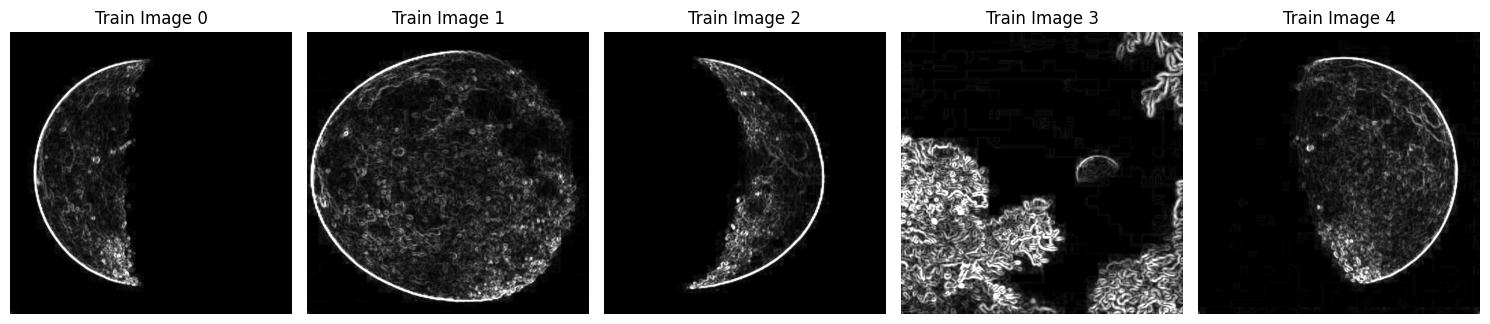

In [60]:
import matplotlib.pyplot as plt
import glob

def show_processed_images(split="train", num=5):
    image_paths = sorted(glob.glob(f"/content/processed/{split}/*.jpg"))

    plt.figure(figsize=(15, 5))
    for i in range(min(num, len(image_paths))):
        image = cv2.imread(image_paths[i], cv2.IMREAD_GRAYSCALE)
        plt.subplot(1, num, i+1)
        plt.imshow(image, cmap='gray')
        plt.title(f"{split.capitalize()} Image {i}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()


show_processed_images(split="train", num=5)


In [61]:
import glob

def count_images(split):
    image_paths = glob.glob(f"/content/processed/{split}/*.jpg")
    return len(image_paths)


train_count = count_images("train")
valid_count = count_images("valid")
test_count  = count_images("test")

print(f" Processed Images:")
print(f"Train: {train_count}")
print(f"Valid: {valid_count}")
print(f"Test : {test_count}")


 Processed Images:
Train: 415
Valid: 119
Test : 66


<div style="font-size: 22px; color:#800080;">
🌕 ** to see the result from every step.**  
</div>


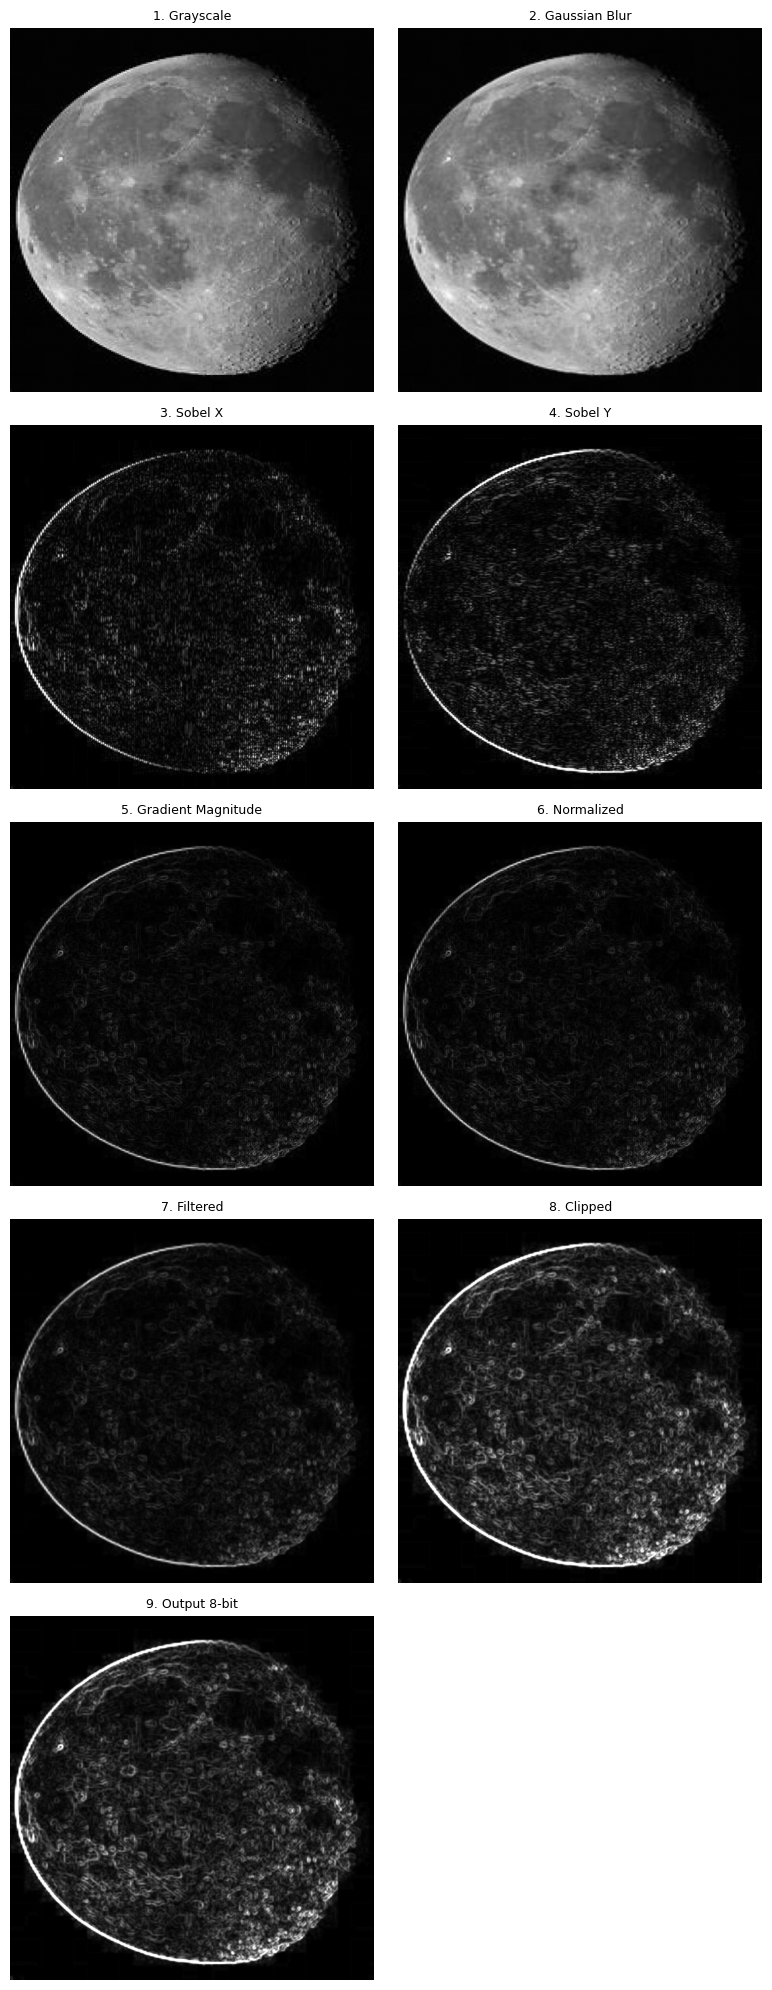

In [62]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

def preprocess_image_preview_grid(image_path):
    if not os.path.exists(image_path):
        raise ValueError(f"❌ Image not found: {image_path}")

    steps = []
    titles = []

    # Step 1: Grayscale
    gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    steps.append(gray)
    titles.append("1. Grayscale")

    # Step 2: Gaussian Blur
    blurred = cv2.GaussianBlur(gray, (3, 3), 0)
    steps.append(blurred)
    titles.append("2. Gaussian Blur")

    # Step 3: Sobel X and Y
    sobel_x = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)
    sobel_x_vis = cv2.convertScaleAbs(sobel_x)
    sobel_y_vis = cv2.convertScaleAbs(sobel_y)
    steps.extend([sobel_x_vis, sobel_y_vis])
    titles.extend(["3. Sobel X", "4. Sobel Y"])

    # Step 4: Gradient Magnitude
    gradient_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)
    steps.append(gradient_magnitude)
    titles.append("5. Gradient Magnitude")

    # Step 5: Normalize
    gradient_magnitude /= gradient_magnitude.max() + 1e-8
    steps.append(gradient_magnitude)
    titles.append("6. Normalized")

    # Step 6: Apply sharpening filter
    kernel_sharpen = np.array([[0.25, 0.5, 0.25],
                           [0.5, 0.25, 0.5],
                           [0.25, 0.5, 0.25]])

    filtered = cv2.filter2D(gradient_magnitude, -1, kernel_sharpen)
    steps.append(filtered)
    titles.append("7. Filtered")

    # Step 7: Clip
    clipped = np.clip(filtered, 0, 1)
    steps.append(clipped)
    titles.append("8. Clipped")

    # Step 8: Convert to 8-bit
    output_img = (clipped * 255).astype(np.uint8)
    steps.append(output_img)
    titles.append("9. Output 8-bit")

    # Arrange images in 2 columns
    num_images = len(steps)
    cols = 2
    rows = (num_images + 1) // 2  # to handle odd number of images

    plt.figure(figsize=(8, 4 * rows))
    for i, (img, title) in enumerate(zip(steps, titles)):
        plt.subplot(rows, cols, i + 1)
        cmap = 'gray' if len(img.shape) == 2 else None
        plt.imshow(img, cmap=cmap)
        plt.title(title, fontsize=9)
        plt.axis('off')

    plt.tight_layout()
    plt.show()
preprocess_image_preview_grid(train_data[1][0])



<div style="font-size: 22px;color:#000000;">
🌕 ** class distribution bar plot .**  
</div>


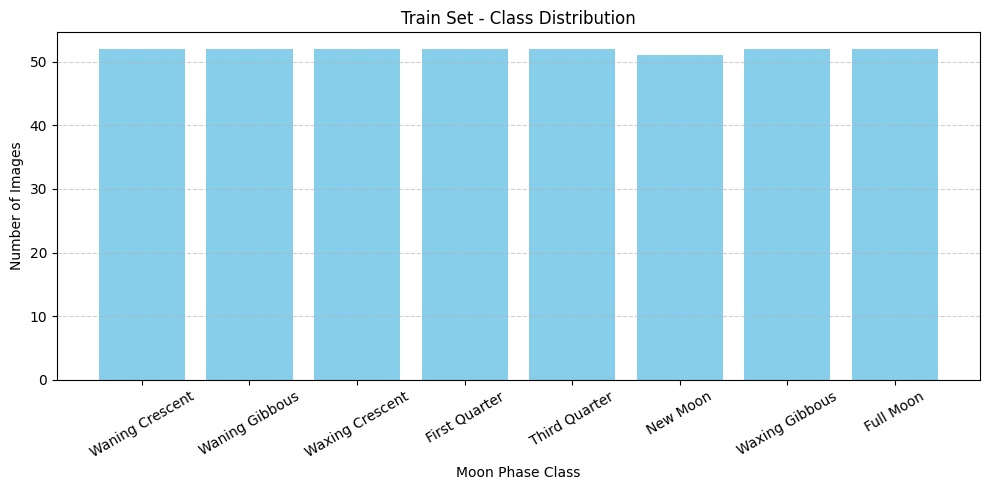

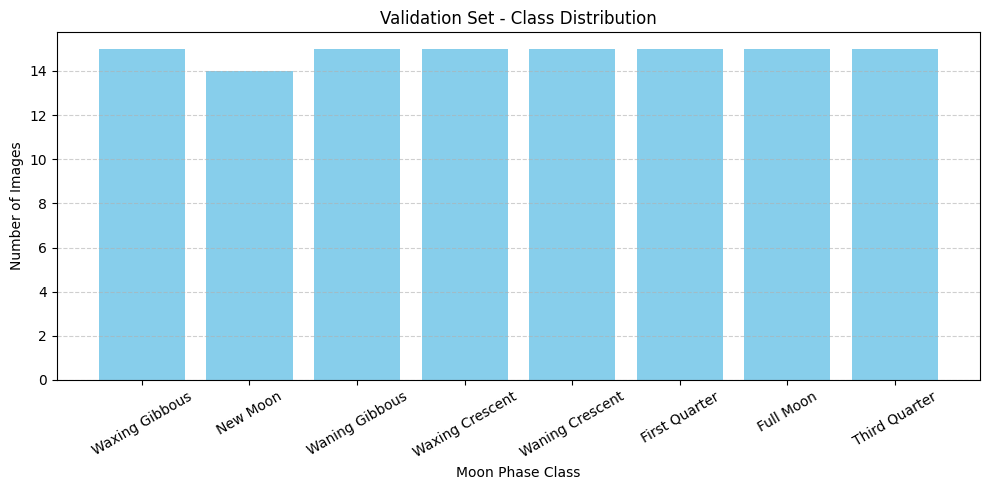

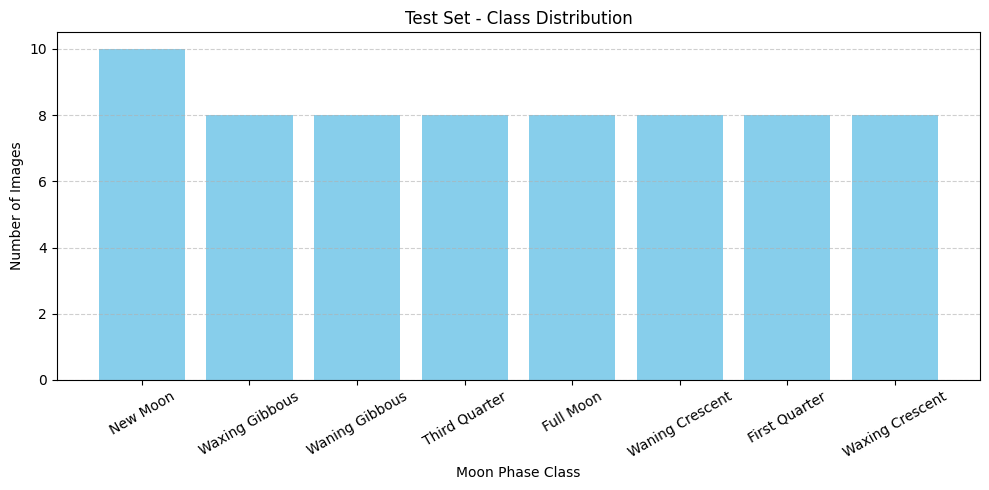

In [63]:
import matplotlib.pyplot as plt
from collections import Counter


label_names = {
    0: "First Quarter",
    1: "Full Moon",
    2: "New Moon",
    3: "Third Quarter",
    4: "Waning Gibbous",
    5: "Waning Crescent",
    6: "Waxing Crescent",
    7: "Waxing Gibbous"
}

def plot_class_distribution(data, title="Class Distribution"):
    labels = [label for _, label in data]
    count = Counter(labels)

    names = [label_names.get(i, str(i)) for i in count.keys()]
    values = list(count.values())

    plt.figure(figsize=(10, 5))
    plt.bar(names, values, color='skyblue')
    plt.title(title)
    plt.xlabel("Moon Phase Class")
    plt.ylabel("Number of Images")
    plt.xticks(rotation=30)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


plot_class_distribution(train_data, title="Train Set - Class Distribution")
plot_class_distribution(valid_data, title="Validation Set - Class Distribution")
plot_class_distribution(test_data, title="Test Set - Class Distribution")


<div style="font-size: 22px; color:#000000;">
🌕 **Model part.**  
after preprocess the data now we want to build the model.
</div>


<div style="font-size: 22px; color:#800080;">
🌕 **Model 1 : ResNet-18.**  

</div>

In [64]:
#torch: used to create tensors and perform computations on
#the CPU or GPU.
import torch
import torch.nn as nn
import torch.optim as optim
#model:Provides access to pretrained CNNs
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
#Image:For loading and processing images.
#Example: Image.open("moon.jpg").convert("RGB")
from PIL import Image
#os:File and path handling
import os


In [65]:
""" Creating a custom dataset class that inherits from torch.utils.data.Dataset """
class MoonPhaseDataset(Dataset):
    def __init__(self, data, transform=None):
        self.data = data              # List of (image_path, class_id)
        self.transform = transform   # Optional transformations (resize, normalize, etc.)

    def __len__(self):
        return len(self.data)        # Return number of samples in the dataset

    def __getitem__(self, idx):
        img_path, label = self.data[idx]                 # Get image path and its label
        image = Image.open(img_path).convert("L")        # Open image as grayscale

        image = image.convert("RGB")                     # Convert to RGB (for pretrained models)

        if self.transform:
            image = self.transform(image)                # Apply transforms if provided

        return image, label                              # Return image and label as a pair


In [66]:
image_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
]) 
""" first will resized image to (224 X 224) to make all images same size 
       then will use ToTensor() to :
       1. make type of image torch.Tensor to let pyTorch use it in Mathematical operations
       2. let image pixel be between 0 and 1 for stable train """
                                     
#to load data and apply transform 
train_dataset = MoonPhaseDataset(train_data, transform=image_transforms)
valid_dataset = MoonPhaseDataset(valid_data, transform=image_transforms)

#load data with applyed transform to DataLoader 
#batch_size=32 : model will see 32 images each time 
# shuffle the images in train to prevents bias and allows the model to see more variation in each batch
#shuffle=False : we do not shuffle images in valid because We need the evaluation to be consistent and comparable
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)


In [67]:
#make sure i use gpu 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=True)#load model ResNet18
model.fc = nn.Linear(model.fc.in_features, 8)  # change last layer of model from 1000 to 8 classes
model = model.to(device) #put model in GPU device


The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.


In [68]:
criterion = nn.CrossEntropyLoss() #Loss Function (it is good for Multi-class Classification)
optimizer = optim.Adam(model.parameters(), lr=0.0001)
#Adam : update the weights of a neural network during training
#lr (how many step the model take during learn) : we choose small value because makes the model learn slowly and gradually(best when using a pretrained model)


In [69]:
def train_model(model, train_loader, valid_loader, criterion, optimizer, epochs=10):
    for epoch in range(epochs):
        model.train()
        train_loss, train_correct = 0, 0

         # pass train images to the model 
         #calculate the loss of train using loss function(criterion( , ))
         # change the weight according to the loss by optimizer 
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
           #calculat the number of images model predected righ 
            _, preds = torch.max(outputs, 1) 
            train_correct += torch.sum(preds == labels)

        train_acc = train_correct.double() / len(train_loader.dataset)

        # Validation
        model.eval()
        valid_loss, valid_correct = 0, 0
        with torch.no_grad():
            # pass valid images to the model 
            #calculate the loss of valid using loss function(criterion( , ))
            #no optimize in valid 
            for imgs, labels in valid_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                valid_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                valid_correct += torch.sum(preds == labels)

        valid_acc = valid_correct.double() / len(valid_loader.dataset)
        
        #print the result of accuracy
        print(f"Epoch {epoch+1}/{epochs} → Train Acc: {train_acc * 100:.2f}%, Valid Acc: {valid_acc * 100:.2f}%")

    print("\n Final Results:")
    print(f"Train Accuracy: {train_acc * 100:.2f}% | Validation Accuracy: {valid_acc * 100:.2f}%")   


In [70]:
# start training the model 
train_model(model, train_loader, valid_loader, criterion, optimizer, epochs=10)


Epoch 1/10 → Train Acc: 57.11%, Valid Acc: 60.50%
Epoch 2/10 → Train Acc: 89.40%, Valid Acc: 68.07%
Epoch 3/10 → Train Acc: 97.83%, Valid Acc: 75.63%
Epoch 4/10 → Train Acc: 99.76%, Valid Acc: 80.67%
Epoch 5/10 → Train Acc: 100.00%, Valid Acc: 78.99%
Epoch 6/10 → Train Acc: 100.00%, Valid Acc: 79.83%
Epoch 7/10 → Train Acc: 100.00%, Valid Acc: 79.83%
Epoch 8/10 → Train Acc: 100.00%, Valid Acc: 81.51%
Epoch 9/10 → Train Acc: 100.00%, Valid Acc: 84.03%
Epoch 10/10 → Train Acc: 100.00%, Valid Acc: 84.03%

 Final Results:
Train Accuracy: 100.00% | Validation Accuracy: 84.03%


<div style="font-size: 22px; color:#800080;">
🌕 **Test.**  
here we want to test the model we are trained.
</div>


In [71]:
#start prepare the test data same as we did for train and valid data
#apply transform (resize() and ToTensor())
#we do not need to shaffle the test images 
test_dataset = MoonPhaseDataset(test_data, transform=image_transforms)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [72]:

def test_model(model, test_loader):#pass test imges to the model and calculat correct predicted of the model 
    model.eval() #tell the model we are in test phase 
    correct = 0 #number of correct prediction 
    total = 0 #number of train images the model see 

    with torch.no_grad(): # save memory and make evaluation faster 
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs) #pass images to get predicting 
            _, predicted = torch.max(outputs, 1) #choose best prediction from multi predicting 
            total += labels.size(0) #calculate number of correct predicting 
            correct += (predicted == labels).sum().item()  
   #print result 
    accuracy = correct / total
    print(f"✅ Test Accuracy: {accuracy * 100:.2f}")


In [73]:
#start testing 
test_model(model, test_loader)


✅ Test Accuracy: 84.85


<div style="font-size: 22px; color:#800080;">
🌕 **Model 2 : DenseNet-121.***  

</div>


In [74]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



In [75]:
#load DenseNet-121 model 
model = models.densenet121(weights=DenseNet121_Weights.DEFAULT)
model.classifier = nn.Linear(model.classifier.in_features, 8)  # 8 moon phases
model = model.to(device)



In [76]:
#apply trnsformation on images 

In [77]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),                
    transforms.RandomHorizontalFlip(),             
    transforms.RandomRotation(5),                 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

valid_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),                 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


In [78]:
#load dataset 

In [79]:
def load_data(image_dir, label_dir):
    image_paths = sorted(glob.glob(os.path.join(image_dir, "*.jpg")))
    data = []

    for img_path in image_paths:
        base_name = os.path.basename(img_path).replace(".jpg", ".txt")
        label_path = os.path.join(label_dir, base_name)

        if not os.path.exists(label_path):
            continue

        with open(label_path, 'r') as f:
            first_line = f.readline().strip()
            if first_line:
                class_id = int(first_line.split()[0])
                data.append((img_path, class_id))

    return data


In [80]:
#Prepare Datasets and Dataloaders

In [81]:
base_path = r"Phase-Your-Moon-1"
train_data = load_data(f"{base_path}/train/images", f"{base_path}/train/labels")
valid_data = load_data(f"{base_path}/valid/images", f"{base_path}/valid/labels")
test_data  = load_data(f"{base_path}/test/images",  f"{base_path}/test/labels")

class MoonPhaseDataset(Dataset):
    def __init__(self, data, transform=None):
        self.data = data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    
    def __getitem__(self, idx):
        img_path, label = self.data[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

train_dataset = MoonPhaseDataset(train_data, transform=train_transforms)
valid_dataset = MoonPhaseDataset(valid_data, transform=valid_test_transforms)
test_dataset = MoonPhaseDataset(test_data, transform=valid_test_transforms)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=16, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)


In [82]:
#Loss, Optimizer, Scheduler

In [83]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)


In [84]:
#Training with Early Stopping

In [85]:
def train_model(model, train_loader, valid_loader, criterion, optimizer, scheduler, epochs=5):
    best_valid_acc = 0.0
    epochs_without_improvement = 0
    patience = 6

    train_accs = []
    valid_accs = []

    for epoch in range(epochs):
        model.train()
        train_correct = 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            train_correct += torch.sum(preds == labels)

        train_acc = train_correct.double() / len(train_loader.dataset)
        train_accs.append(train_acc)

        # Validation
        model.eval()
        valid_correct = 0
        with torch.no_grad():
            for imgs, labels in valid_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                _, preds = torch.max(outputs, 1)
                valid_correct += torch.sum(preds == labels)

        valid_acc = valid_correct.double() / len(valid_loader.dataset)
        valid_accs.append(valid_acc)

        # Early stopping
        if valid_acc > best_valid_acc:
            best_valid_acc = valid_acc
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f" Early stopping triggered after {epoch+1} epochs!")
            break

        scheduler.step()
        print(f"Epoch {epoch+1}/{epochs} → Train Acc: {train_acc:.4f}, Valid Acc: {valid_acc:.4f}")

    return train_accs, valid_accs


In [86]:

train_accs, valid_accs = train_model(model, train_loader, valid_loader, criterion, optimizer, scheduler, epochs=10)


Epoch 1/10 → Train Acc: 0.3494, Valid Acc: 0.5798
Epoch 2/10 → Train Acc: 0.6867, Valid Acc: 0.6807
Epoch 3/10 → Train Acc: 0.7952, Valid Acc: 0.7395
Epoch 4/10 → Train Acc: 0.8771, Valid Acc: 0.7563
Epoch 5/10 → Train Acc: 0.9205, Valid Acc: 0.7731
Epoch 6/10 → Train Acc: 0.9566, Valid Acc: 0.7479
Epoch 7/10 → Train Acc: 0.9711, Valid Acc: 0.7647
Epoch 8/10 → Train Acc: 0.9759, Valid Acc: 0.7647
Epoch 9/10 → Train Acc: 0.9807, Valid Acc: 0.7815
Epoch 10/10 → Train Acc: 0.9807, Valid Acc: 0.8067


In [87]:
#Test Model

In [88]:
def test_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = correct / total
    print(f"✅ Test Accuracy: {accuracy * 100:.2f}%")
    return accuracy


In [89]:

test_accuracy = test_model(model, test_loader)

✅ Test Accuracy: 83.33%


In [90]:
#Classification Report

In [91]:
from sklearn.metrics import classification_report


label_names = [
    "First Quarter", "Full Moon", "New Moon", "Third Quarter",
    "Waning Gibbous", "Waning Crescent", "Waxing Crescent", "Waxing Gibbous"
]

def classification_report_model(model, test_loader, label_names):
    model.eval()
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, predicted = torch.max(outputs, 1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    print(" Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=label_names, digits=2))


In [92]:

classification_report_model(model, test_loader, label_names)

 Classification Report:
                 precision    recall  f1-score   support

  First Quarter       1.00      1.00      1.00         8
      Full Moon       0.88      0.88      0.88         8
       New Moon       0.77      1.00      0.87        10
  Third Quarter       0.78      0.88      0.82         8
 Waning Gibbous       1.00      0.88      0.93         8
Waning Crescent       0.43      0.38      0.40         8
Waxing Crescent       1.00      0.62      0.77         8
 Waxing Gibbous       0.89      1.00      0.94         8

       accuracy                           0.83        66
      macro avg       0.84      0.83      0.83        66
   weighted avg       0.84      0.83      0.83        66



In [93]:
#Final Accuracy Summary

In [94]:
def print_final_accuracies(train_accs, valid_accs, test_accuracy):
    print("📊 Final Accuracies:")
    print(f"  • Training Accuracy: {train_accs[-1]*100:.2f}%")
    print(f"  • Validation Accuracy: {valid_accs[-1]*100:.2f}%")
    print(f"  • Test Accuracy: {test_accuracy*100:.2f}%")


In [95]:

print_final_accuracies(train_accs, valid_accs, test_accuracy)


📊 Final Accuracies:
  • Training Accuracy: 98.07%
  • Validation Accuracy: 80.67%
  • Test Accuracy: 83.33%


<div style="font-size: 22px;color:#000000;">
🌕 ** summary of the models .**  
</div>


In [96]:
# First, collect all true and predicted labels from the test set
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


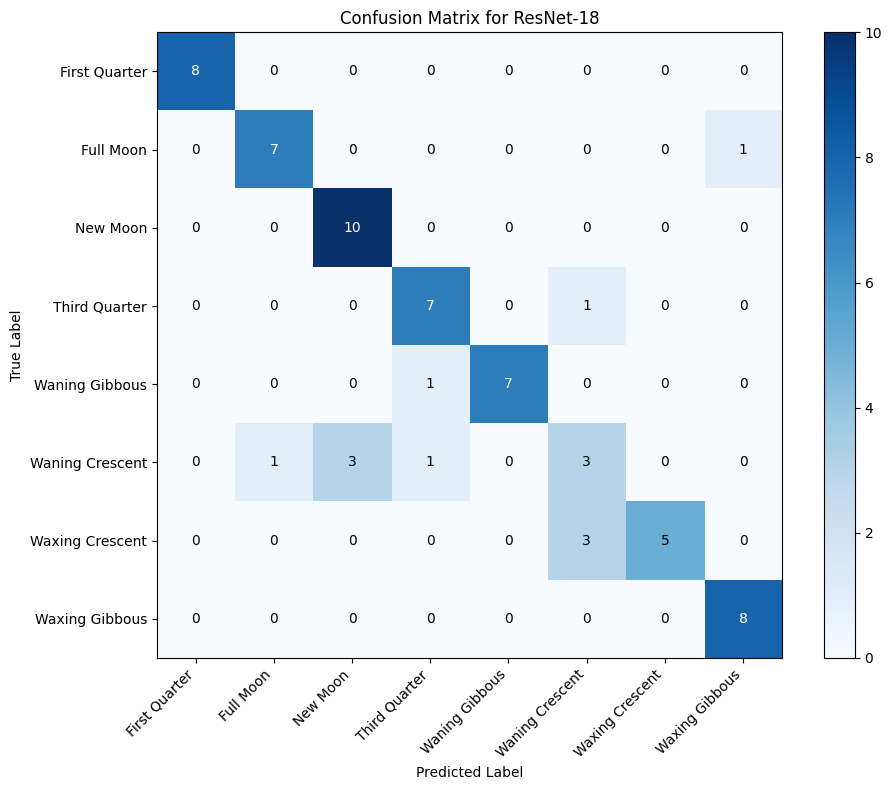

 Classification Report for ResNet-18:

                 precision    recall  f1-score   support

  First Quarter       1.00      1.00      1.00         8
      Full Moon       0.88      0.88      0.88         8
       New Moon       0.77      1.00      0.87        10
  Third Quarter       0.78      0.88      0.82         8
 Waning Gibbous       1.00      0.88      0.93         8
Waning Crescent       0.43      0.38      0.40         8
Waxing Crescent       1.00      0.62      0.77         8
 Waxing Gibbous       0.89      1.00      0.94         8

       accuracy                           0.83        66
      macro avg       0.84      0.83      0.83        66
   weighted avg       0.84      0.83      0.83        66



In [97]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

# Class names
class_names = [
    "First Quarter", "Full Moon", "New Moon", "Third Quarter",
    "Waning Gibbous", "Waning Crescent", "Waxing Crescent", "Waxing Gibbous"
]

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot using matplotlib only
plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix for ResNet-18")
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha='right')
plt.yticks(tick_marks, class_names)

# Add counts in the boxes
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

# Print detailed metrics
print(" Classification Report for ResNet-18:\n")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=2))


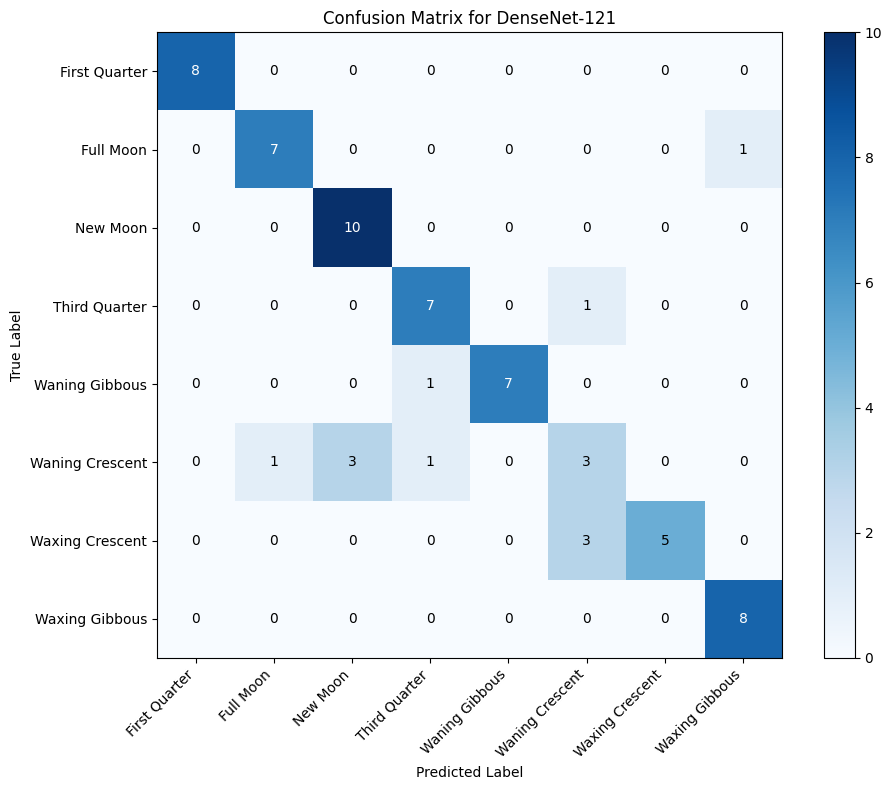


 Classification Report of DenseNet-121 :
                 precision    recall  f1-score   support

  First Quarter       1.00      1.00      1.00         8
      Full Moon       0.88      0.88      0.88         8
       New Moon       0.77      1.00      0.87        10
  Third Quarter       0.78      0.88      0.82         8
 Waning Gibbous       1.00      0.88      0.93         8
Waning Crescent       0.43      0.38      0.40         8
Waxing Crescent       1.00      0.62      0.77         8
 Waxing Gibbous       0.89      1.00      0.94         8

       accuracy                           0.83        66
      macro avg       0.84      0.83      0.83        66
   weighted avg       0.84      0.83      0.83        66



In [98]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

# Collect predictions and labels
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Define class names in correct order
class_names = [
    "First Quarter", "Full Moon", "New Moon", "Third Quarter",
    "Waning Gibbous", "Waning Crescent", "Waxing Crescent", "Waxing Gibbous"
]

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot with matplotlib
plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix for DenseNet-121")
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha="right")
plt.yticks(tick_marks, class_names)

# Add counts to the grid
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

# Print the full classification report
print("\n Classification Report of DenseNet-121 :")
report = classification_report(all_labels, all_preds, target_names=class_names, digits=2)
print(report)
